<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day13_practice2_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# GAN(이미지생성) = 생성자(위조지폐범) vs 판별자(경찰)의 경쟁 학습
# 순수 노이즈에서 손글씨 숫자가 '생겨나는' 과정

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 20
NOISE_DIM = 64 # 생성자의 입력: 의미 없는 난수 64개

In [10]:
# 셀 1. 데이터 - MNIST 손글씨
def load_mnist(root="./data"):
  tf = transforms.ToTensor() # 이미지(0-255) → 텐서(0.0-1.0)로 변환
  return datasets.MNIST(root=root, train=True, download=True, transform=tf)

train_data = load_mnist()
loader = DataLoader(train_data, batch_size=256, shuffle=True) # 256장씩 묶고 매 에폭 섞기

In [11]:
# 셀 2. 생성자 G와 판별자 D

# 위조지폐범. 생성자(Generator): 난수 64개 → 가짜 이미지 784
G = nn.Sequential( # 디코더
    nn.Linear(NOISE_DIM, 256), nn.ReLU(),
    nn.Linear(256, 512), nn.ReLU(), # 렐루(ReLU - Rectified Linear Unit): 출력 0 또는 양의 무한대, 음수 → 0
    nn.Linear(512, 784), nn.Tanh(), # 하이퍼볼릭 탄젠트 (Hyperbolic Tangent, Tanh) : 출력 -1과 1 사이
).to(device)

# 경찰. 판별자(Discriminator): 이미지 784 → 진짜일 확률 1개
D = nn.Sequential( # 이진 분류기
    nn.Flatten(), # (1,28,28) → 784
    nn.Linear(784, 256),
    nn.LeakyReLU(0.2), # LeakyReLU: 음수도 0.2배 통과 (GAN 관련), 음수×0.2
    nn.Linear(256, 1),
    nn.Sigmoid(), # 진짜일 확률
).to(device)

loss_fn = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

In [14]:
# 셀 3. 경쟁 학습 - 한 배치마다 두 번의 학습
fixed_noise = torch.randn(16, NOISE_DIM).to(device) # 고정 난수 16개 (성장 관찰용), 16×64
snapshots = {} # {에폭: [생성이미지 16개]} 저장용 딕셔너리

for epoch in range(EPOCHS):
  for real, _ in loader: # 진짜 이미지 배치
    real = real.reshape(-1, 784).to(device) # (8,1,28,28) → (8,784)
    B = real.size(0) # 이번 에폭의 배치 크기
    ones, zeros = torch.ones(B, 1).to(device),torch.zeros(B, 1).to(device) # 정답표: 진짜는 (B,1), 가짜는 (B,0) 모양

    # 경찰 판별자(D) 훈련: 진짜는 1, 가짜는 0 이라고 맞히도록, 진짜와 가짜를 잘 구분하도록 훈련
    fake = G(torch.randn(B, NOISE_DIM).to(device)) # G에 무작위 난수를 입력해서 배치 크기 만큼의 가짜 이미지를 생성
    d_loss = loss_fn(D(real), ones) + loss_fn(D(fake.detach()), zeros) # D 손실 = 진짜를 1로 + 가짜를 0으로 (두 손실의 합), .detach() 값만 가져온- 이 손실로 G는 안 건드림(D만 학습)
    opt_D.zero_grad() # D 갱신
    d_loss.backward()
    opt_D.step()

    # 위조범 생성자(G) 훈련: 경찰이 '진짜(1)'라고 속도록
    fake = G(torch.randn(B, NOISE_DIM).to(device)) # 새 가짜 생성 이미지 (이번엔 detach 안 함), 생성자를 학습시킬 것이므로
    g_loss = loss_fn(D(fake), ones) # 가짜인데 정답을 1로 속이는게 목표, 가짜 이미지가 진짜 이미지와 얼마나 차이가 나는지
    opt_G.zero_grad() # G 갱신
    g_loss.backward()
    opt_G.step()

  print(f"epoch {epoch+1:2d}/{EPOCHS} | D loss {d_loss.item():.3f} | G loss {g_loss.item():.3f}")
  # 특정 에폭(첫, 중간, 마지막)에만 스냅샷 저장
  if epoch + 1 in {1, EPOCHS // 2, EPOCHS}:
    with torch.no_grad():
      snapshots[epoch + 1] = G(fixed_noise).reshape(-1, 1, 28, 28).cpu()

epoch  1/20 | D loss 0.705 | G loss 1.654
epoch  2/20 | D loss 1.354 | G loss 0.687
epoch  3/20 | D loss 1.273 | G loss 0.785
epoch  4/20 | D loss 1.317 | G loss 0.793
epoch  5/20 | D loss 1.410 | G loss 0.717
epoch  6/20 | D loss 1.229 | G loss 0.781
epoch  7/20 | D loss 1.180 | G loss 0.770
epoch  8/20 | D loss 0.972 | G loss 0.897
epoch  9/20 | D loss 1.284 | G loss 0.808
epoch 10/20 | D loss 0.679 | G loss 1.610
epoch 11/20 | D loss 1.489 | G loss 1.155
epoch 12/20 | D loss 1.767 | G loss 0.934
epoch 13/20 | D loss 1.167 | G loss 0.751
epoch 14/20 | D loss 0.711 | G loss 1.315
epoch 15/20 | D loss 1.213 | G loss 1.186
epoch 16/20 | D loss 0.879 | G loss 1.268
epoch 17/20 | D loss 1.117 | G loss 1.048
epoch 18/20 | D loss 0.816 | G loss 1.368
epoch 19/20 | D loss 1.498 | G loss 1.018
epoch 20/20 | D loss 0.977 | G loss 1.505


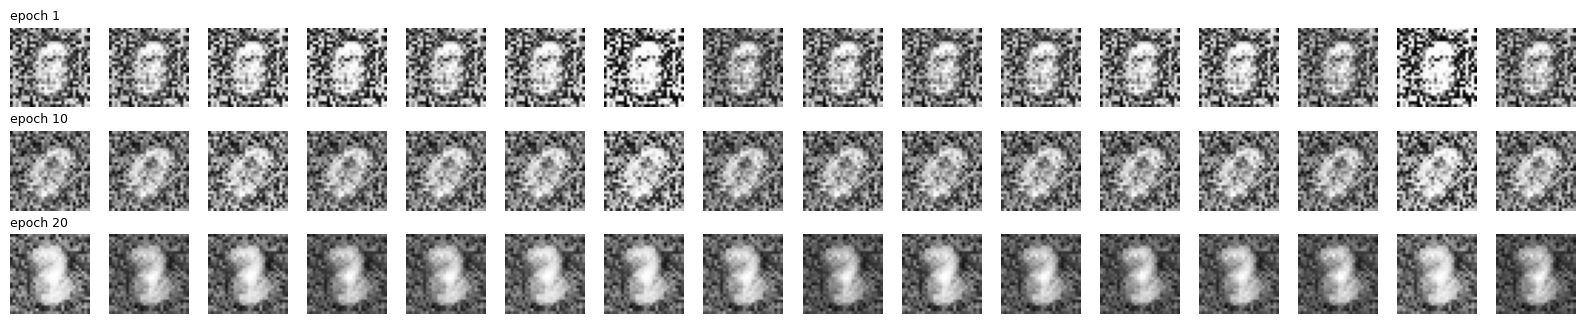

In [15]:
# 셀 4. 노이즈가 숫자가 되기까지 과정
fig, axes = plt.subplots(len(snapshots), 16, figsize=(16, len(snapshots) * 1.1), squeeze=False)
for row, (ep, imgs) in enumerate(sorted(snapshots.items())):
  for col in range(16):
    ax = axes[row, col]
    ax.imshow(imgs[col][0], cmap="gray"); ax.axis("off")
    if col == 0:
      ax.set_title(f"epoch {ep}", loc="left", fontsize=9) # 행 맨 앞에 에폭 표시
plt.tight_layout()
plt.savefig("plot1_gan_growth.png")
plt.show()

In [ ]:
# 생성자는 판별자라는 평가자를 속이기 위해 피드백을 받아가며 픽셀 구성을 진짜 데이터처럼 끊임없이 발전시켜 나가는 것